# Latest upper PPO model versus baselines

This notebook evaluates the latest saved upper model against two references under identical scenarios and seeds:

- **Rule baseline:** above-average gNB-slices receive bias `-0.8`, below-average pairs receive `+0.4`, and pairs inside a 0.05 deadband receive zero.
- **Neutral baseline:** all upper biases are zero.

All controllers use the same directional lower heuristic, safe-admission layer, radio simulator, UE trajectories, and episode durations. This isolates the value of the upper controller.

> Important: the saved PPO was trained before the SLA definitions were corrected. This notebook evaluates it using the current corrected window-based SLA implementation.

In [1]:
import json, os
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from stable_baselines3 import PPO

from global_ppo_3gnb_env import GlobalPPO3GNBEnv, SLICE_TYPES
from upper_agent_training_scenarios import UPPER_TRAINING_SCENARIOS

plt.style.use('seaborn-v0_8-whitegrid')
RUN_DIR = sorted((ROOT/'models/upper_ppo_3gnb').glob('run_*'), key=lambda p:p.stat().st_mtime)[-1]
config = json.loads((RUN_DIR/'config.json').read_text())
MODEL_PATH = RUN_DIR/'upper_ppo_final.zip'
model = PPO.load(MODEL_PATH)
SCENARIO_NAMES = [scenario.name for scenario in UPPER_TRAINING_SCENARIOS]
EVAL_SEED = 71
print('Model:', MODEL_PATH)
print('Scenarios:', SCENARIO_NAMES)


Model: /home/oussama/Desktop/chech/models/upper_ppo_3gnb/run_20260619_143855/upper_ppo_final.zip
Scenarios: ['embb_g0_to_g1_slow', 'urllc_g1_to_g2_slow', 'mmtc_g2_to_g0_slow', 'mixed_g0_release', 'three_way_slice_conflict', 'balanced_mixed_hold']


/home/oussama/Desktop/chech/venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## Matched evaluation helpers

Each controller receives its own freshly constructed environment with the same scenario and seed. The rule baseline only reads the current 3×3 load matrix; it does not inspect future mobility or target outcomes.

In [2]:
def make_env(scenario_name, seed):
    return GlobalPPO3GNBEnv(
        seed=seed,
        scenario_mode='curriculum',
        training_scenarios=scenario_name,
        scenario_selection='cycle',
        upper_window_seconds=float(config['upper_window_seconds']),
        local_steps_per_global=int(config['local_steps_per_global']),
        radio_substeps=int(config['radio_substeps']),
        max_prbs_per_ue=config['max_prbs_per_ue'],
        terminal_reward_only=False,
        sla_deadband=float(config['sla_deadband']),
    )


def rule_action(obs, deadband=0.05):
    loads = np.asarray(obs[:9], dtype=float).reshape(3, 3)
    means = loads.mean(axis=0, keepdims=True)
    action = np.zeros_like(loads)
    action[loads > means + deadband] = -0.8
    action[loads < means - deadband] = +0.4
    return action.reshape(-1).astype(np.float32)


def select_action(controller, obs):
    if controller == 'PPO':
        action, _ = model.predict(obs, deterministic=True)
        return np.asarray(action, dtype=np.float32)
    if controller == 'Rule baseline':
        return rule_action(obs)
    return np.zeros(9, dtype=np.float32)


def run_episode(controller, scenario_name, seed):
    env = make_env(scenario_name, seed)
    obs, reset_info = env.reset(seed=seed)
    initial_load = np.asarray(reset_info['load_matrix'], dtype=float)
    rows = []
    done = False
    while not done:
        action = select_action(controller, obs)
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
        admission = info['safe_admission']['stats']
        rows.append({
            'controller': controller,
            'scenario_name': scenario_name,
            'seed': seed,
            'time_s': info['episode_time_s'],
            'reward': reward,
            'load_variance': info['load_variance'],
            'sla_count': info['sla_count'],
            'sla_severity': info['sla_severity'],
            'handovers': info['handover_count'],
            'eligible': admission['eligible'],
            'accepted': admission['accepted'],
            'target_safety_rejections': admission['rejected_target_safety'],
            'action_abs_mean': float(np.mean(np.abs(action))),
            'action_saturation': float(np.mean(np.abs(action) >= 0.95)),
            'load_matrix': np.asarray(info['load_matrix'], dtype=float),
            'bias_matrix': np.asarray(info['bias_matrix'], dtype=float),
            'offset_tensor': np.asarray(info['directional_offset_tensor'], dtype=float),
            'sla_violation_matrix': np.asarray(info['sla_violation_matrix'], dtype=float),
            'sla_severity_matrix': np.asarray(info['sla_severity_matrix'], dtype=float),
        })
    env.close()
    trace = pd.DataFrame(rows)
    final_load = trace.iloc[-1].load_matrix
    per_slice_before = np.var(initial_load, axis=0)
    per_slice_after = np.var(final_load, axis=0)
    summary = {
        'controller': controller,
        'scenario_name': scenario_name,
        'seed': seed,
        'episode_return': trace.reward.sum(),
        'variance_before': per_slice_before.sum(),
        'variance_after': per_slice_after.sum(),
        'variance_improvement': (per_slice_before-per_slice_after).sum(),
        'embb_improvement': per_slice_before[0]-per_slice_after[0],
        'urllc_improvement': per_slice_before[1]-per_slice_after[1],
        'mmtc_improvement': per_slice_before[2]-per_slice_after[2],
        'mean_sla_severity': trace.sla_severity.mean(),
        'final_sla_count': trace.sla_count.iloc[-1],
        'total_handovers': trace.handovers.sum(),
        'total_accepted': trace.accepted.sum(),
        'target_safety_rejections': trace.target_safety_rejections.sum(),
        'mean_action_abs': trace.action_abs_mean.mean(),
        'mean_action_saturation': trace.action_saturation.mean(),
    }
    return trace, summary


## Run all matched comparisons

The full evaluation contains 18 episodes: six scenarios × three controllers. Depending on the machine, this cell can take about one to three minutes.

In [3]:
controllers = ['PPO', 'Rule baseline', 'Neutral baseline']
all_traces, summaries = [], []
for scenario_name in SCENARIO_NAMES:
    for controller in controllers:
        print('Running', scenario_name, '|', controller)
        trace, summary = run_episode(controller, scenario_name, EVAL_SEED)
        all_traces.append(trace)
        summaries.append(summary)
traces = pd.concat(all_traces, ignore_index=True)
summary = pd.DataFrame(summaries)
display(summary.round(4))


Running embb_g0_to_g1_slow | PPO
Running embb_g0_to_g1_slow | Rule baseline
Running embb_g0_to_g1_slow | Neutral baseline
Running urllc_g1_to_g2_slow | PPO
Running urllc_g1_to_g2_slow | Rule baseline
Running urllc_g1_to_g2_slow | Neutral baseline
Running mmtc_g2_to_g0_slow | PPO
Running mmtc_g2_to_g0_slow | Rule baseline
Running mmtc_g2_to_g0_slow | Neutral baseline
Running mixed_g0_release | PPO
Running mixed_g0_release | Rule baseline
Running mixed_g0_release | Neutral baseline
Running three_way_slice_conflict | PPO
Running three_way_slice_conflict | Rule baseline
Running three_way_slice_conflict | Neutral baseline
Running balanced_mixed_hold | PPO
Running balanced_mixed_hold | Rule baseline
Running balanced_mixed_hold | Neutral baseline


,controller,scenario_name,seed,episode_return,variance_before,variance_after,variance_improvement,embb_improvement,urllc_improvement,mmtc_improvement,mean_sla_severity,final_sla_count,total_handovers,total_accepted,target_safety_rejections,mean_action_abs,mean_action_saturation
0,PPO,embb_g0_to_g1_slow,71,0.2742,0.1800,0.0000,0.1800,0.1800,0.0000,0.0000,0.4739,3.0,2,2,13,0.9769,0.9444
1,Rule baseline,embb_g0_to_g1_slow,71,0.3480,0.1800,0.0000,0.1800,0.1800,0.0000,0.0000,0.4739,3.0,2,2,13,0.1111,0.0000
2,Neutral baseline,embb_g0_to_g1_slow,71,-0.1267,0.1800,0.2222,-0.0422,-0.0422,0.0000,0.0000,0.3668,1.0,0,0,0,0.0000,0.0000
3,PPO,urllc_g1_to_g2_slow,71,-0.4566,0.1721,0.2222,-0.0501,0.0000,-0.0501,0.0000,0.9154,2.0,1,1,2,0.9758,0.9500
4,Rule baseline,urllc_g1_to_g2_slow,71,-0.2704,0.1721,0.2222,-0.0501,0.0000,-0.0501,0.0000,0.9154,2.0,1,1,23,0.1933,0.0000
5,Neutral baseline,urllc_g1_to_g2_slow,71,-0.1504,0.1721,0.2222,-0.0501,0.0000,-0.0501,0.0000,0.9154,1.0,0,0,0,0.0000,0.0000
6,PPO,mmtc_g2_to_g0_slow,71,-0.5591,0.1568,0.2222,-0.0654,0.0000,0.0000,-0.0654,0.0000,0.0,1,1,26,0.9922,0.9722
7,Rule baseline,mmtc_g2_to_g0_slow,71,-0.3163,0.1568,0.2222,-0.0654,0.0000,0.0000,-0.0654,0.0000,0.0,1,1,26,0.1822,0.0000
8,Neutral baseline,mmtc_g2_to_g0_slow,71,-0.1963,0.1568,0.2222,-0.0654,0.0000,0.0000,-0.0654,0.0000,0.0,0,0,0,0.0000,0.0000
9,PPO,mixed_g0_release,71,0.1464,0.3850,0.2279,0.1571,0.1015,0.1039,-0.0484,0.7232,7.0,11,11,0,0.9902,0.9676


## Overall comparison

Variance improvement is the main load-balancing metric. Positive is better. SLA severity uses the corrected upper-window definitions, and handovers measure mobility cost.

,mean_return,mean_variance_improvement,positive_scenarios,mean_sla_severity,mean_handovers,mean_action_abs,mean_action_saturation
controller,,,,,,,
Neutral baseline,-0.0837,-0.0279,1,0.4455,0.0000,0.0000,0.0000
PPO,-0.1199,0.0684,3,0.4842,4.1667,0.9650,0.9315
Rule baseline,-0.7893,0.0978,3,0.4807,6.1667,0.3163,0.0000


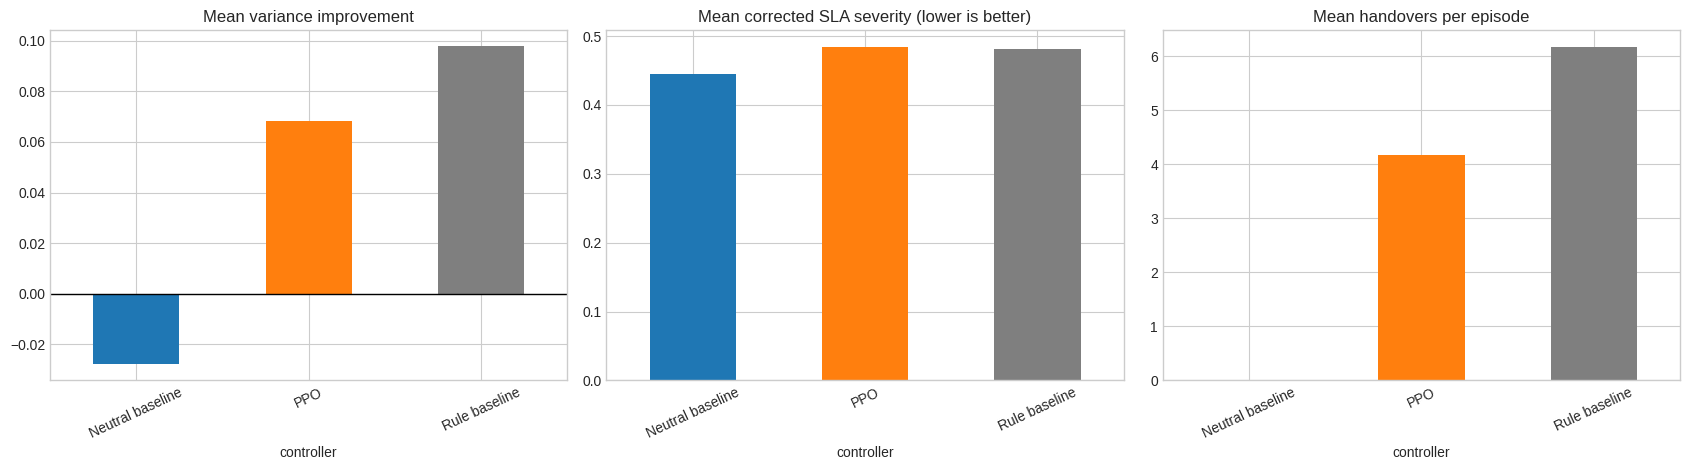

In [4]:
overall = summary.groupby('controller').agg(
    mean_return=('episode_return','mean'),
    mean_variance_improvement=('variance_improvement','mean'),
    positive_scenarios=('variance_improvement',lambda x:int(np.sum(x>0))),
    mean_sla_severity=('mean_sla_severity','mean'),
    mean_handovers=('total_handovers','mean'),
    mean_action_abs=('mean_action_abs','mean'),
    mean_action_saturation=('mean_action_saturation','mean'),
)
display(overall.round(4))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
overall.mean_variance_improvement.plot(kind='bar', ax=axes[0], color=['tab:blue','tab:orange','tab:gray'])
axes[0].axhline(0,color='black',linewidth=1); axes[0].set_title('Mean variance improvement')
overall.mean_sla_severity.plot(kind='bar', ax=axes[1], color=['tab:blue','tab:orange','tab:gray'])
axes[1].set_title('Mean corrected SLA severity (lower is better)')
overall.mean_handovers.plot(kind='bar', ax=axes[2], color=['tab:blue','tab:orange','tab:gray'])
axes[2].set_title('Mean handovers per episode')
for ax in axes: ax.tick_params(axis='x',rotation=25)
plt.tight_layout(); plt.show()


## Scenario-by-scenario load balancing

This is the most important fairness view: every controller is evaluated on the same scenario rather than averaged across different traffic patterns.

controller,Neutral baseline,PPO,Rule baseline
scenario_name,,,
embb_g0_to_g1_slow,-0.0422,0.1800,0.1800
urllc_g1_to_g2_slow,-0.0501,-0.0501,-0.0501
mmtc_g2_to_g0_slow,-0.0654,-0.0654,-0.0654
mixed_g0_release,0.3006,0.1571,0.2168
three_way_slice_conflict,-0.1729,0.3260,0.4427
balanced_mixed_hold,-0.1372,-0.1372,-0.1372


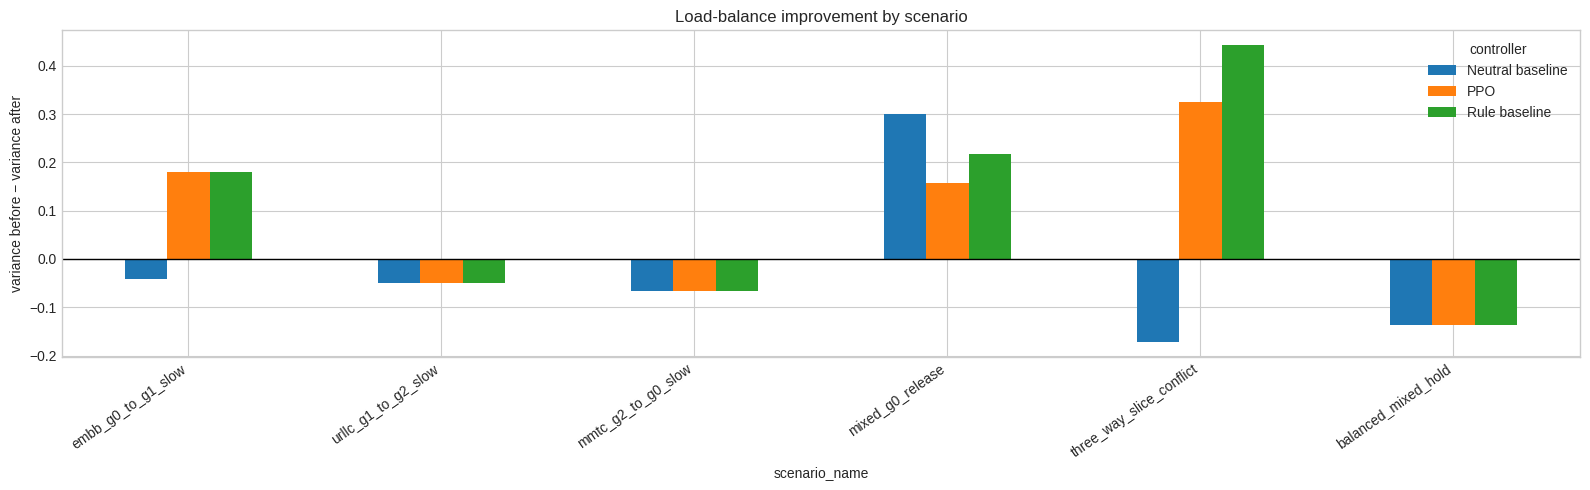

embb_improvement  \
scenario_name            controller                           
embb_g0_to_g1_slow       PPO                         0.1800   
                         Rule baseline               0.1800   
                         Neutral baseline           -0.0422   
urllc_g1_to_g2_slow      PPO                         0.0000   
                         Rule baseline               0.0000   
                         Neutral baseline            0.0000   
mmtc_g2_to_g0_slow       PPO                         0.0000   
                         Rule baseline               0.0000   
                         Neutral baseline            0.0000   
mixed_g0_release         PPO                         0.1015   
                         Rule baseline               0.1512   
                         Neutral baseline            0.1244   
three_way_slice_conflict PPO                         0.1260   
                         Rule baseline               0.1648   
                         Neutral baseline           -0.0422   
balanced_mixed_hold      PPO                        -0.0004   
                         Rule baseline              -0.0004   
                         Neutral baseline           -0.0004   

                                           urllc_improvement  mmtc_improvement  
scenario_name            controller                                             
embb_g0_to_g1_slow       PPO                          0.0000            0.0000  
                         Rule baseline                0.0000            0.0000  
                         Neutral baseline             0.0000            0.0000  
urllc_g1_to_g2_slow      PPO                         -0.0501            0.0000  
                         Rule baseline               -0.0501            0.0000  
                         Neutral baseline            -0.0501            0.0000  
mmtc_g2_to_g0_slow       PPO                          0.0000           -0.0654  
                         Rule baseline                0.0000           -0.0654  
                         Neutral baseline             0.0000           -0.0654  
mixed_g0_release         PPO                          0.1039           -0.0484  
                         Rule baseline                0.0689           -0.0033  
                         Neutral baseline             0.1050            0.0711  
three_way_slice_conflict PPO                          0.1040            0.0960  
                         Rule baseline                0.1589            0.1189  
                         Neutral baseline            -0.0579           -0.0728  
balanced_mixed_hold      PPO                         -0.0686           -0.0683  
                         Rule baseline               -0.0686           -0.0683  
                         Neutral baseline            -0.0686           -0.0683

In [5]:
pivot = summary.pivot(index='scenario_name', columns='controller', values='variance_improvement').loc[SCENARIO_NAMES]
display(pivot.round(4))
pivot.plot(kind='bar', figsize=(16,5))
plt.axhline(0,color='black',linewidth=1)
plt.ylabel('variance before − variance after')
plt.title('Load-balance improvement by scenario')
plt.xticks(rotation=35,ha='right'); plt.tight_layout(); plt.show()

slice_pivot = summary.set_index(['scenario_name','controller'])[['embb_improvement','urllc_improvement','mmtc_improvement']]
display(slice_pivot.round(4))


## Physical-time trajectories

One panel per scenario compares the aggregate spatial load variance throughout the complete episode.

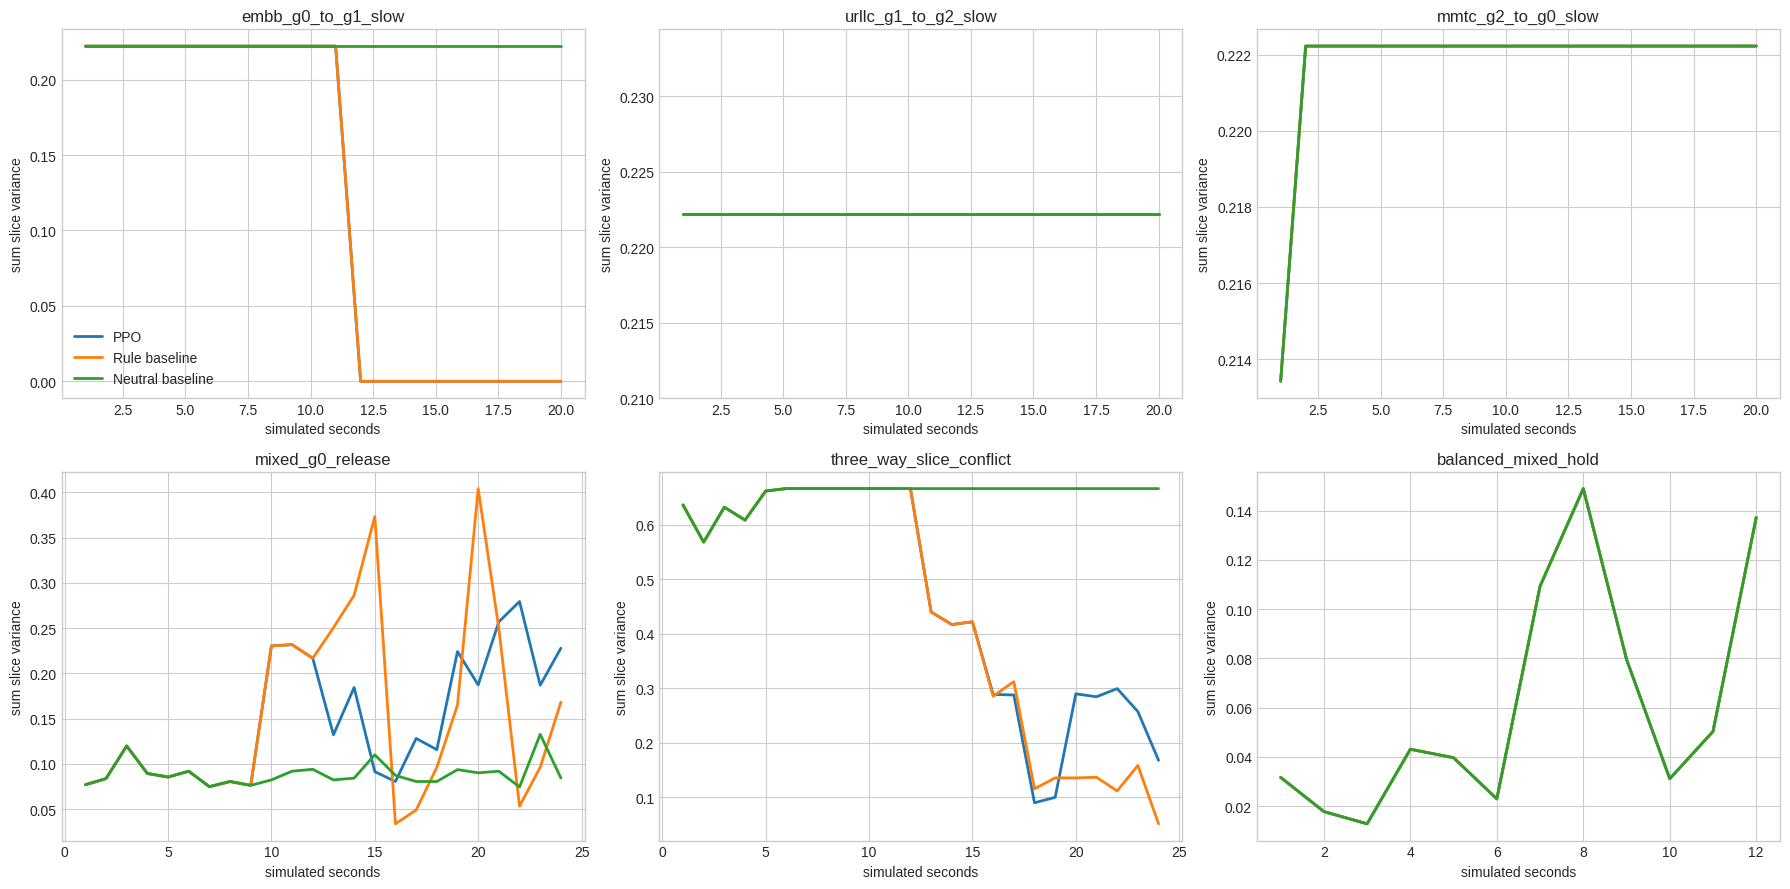

In [6]:
fig, axes = plt.subplots(2,3,figsize=(18,9))
for ax, scenario_name in zip(axes.flat, SCENARIO_NAMES):
    for controller in controllers:
        part = traces[(traces.scenario_name==scenario_name)&(traces.controller==controller)]
        variance = [np.var(matrix,axis=0).sum() for matrix in part.load_matrix]
        ax.plot(part.time_s,variance,linewidth=2,label=controller)
    ax.set_title(scenario_name); ax.set_xlabel('simulated seconds'); ax.set_ylabel('sum slice variance')
axes[0,0].legend()
plt.tight_layout(); plt.show()


## Bias and offset behavior

These plots compare action strength and saturation. The matrix example uses the final step of the three-way conflict scenario.

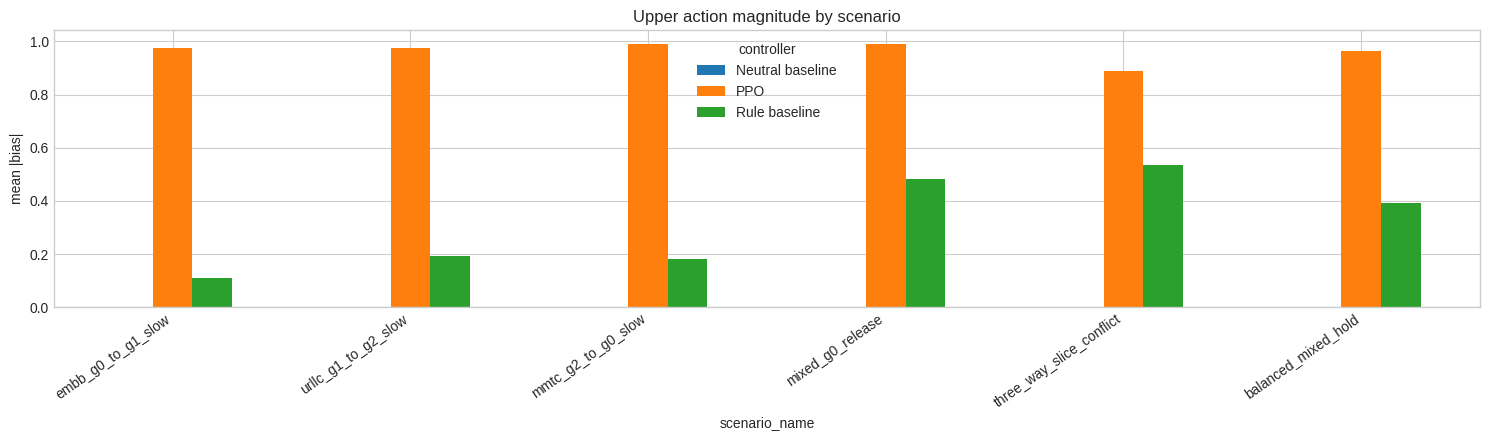

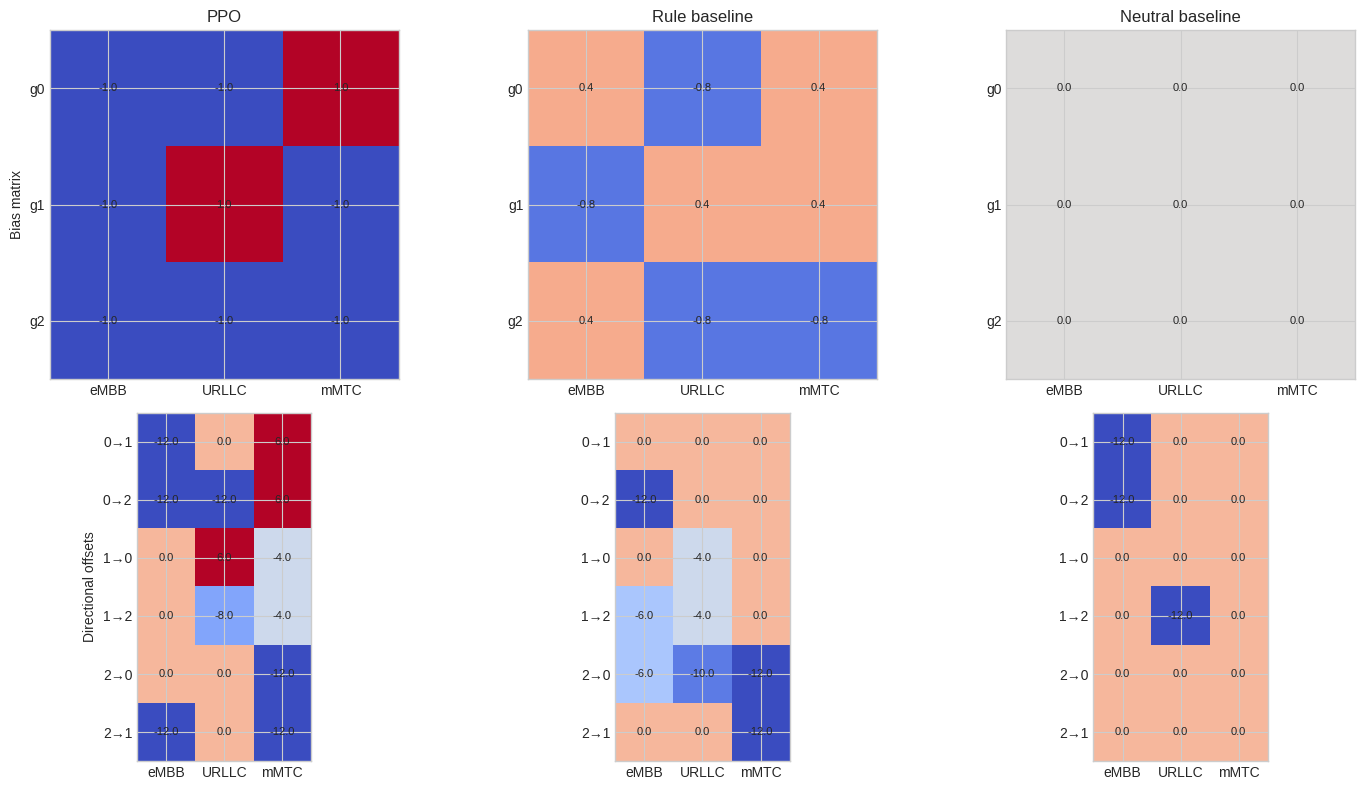

In [7]:
action_compare = summary.pivot(index='scenario_name',columns='controller',values='mean_action_abs').loc[SCENARIO_NAMES]
action_compare.plot(kind='bar',figsize=(15,4.5))
plt.ylabel('mean |bias|'); plt.title('Upper action magnitude by scenario')
plt.xticks(rotation=35,ha='right'); plt.tight_layout(); plt.show()

scenario='three_way_slice_conflict'
fig, axes = plt.subplots(2,3,figsize=(15,8))
for col, controller in enumerate(controllers):
    row = traces[(traces.scenario_name==scenario)&(traces.controller==controller)].iloc[-1]
    bias = row.bias_matrix
    offsets = row.offset_tensor.reshape(6,3)
    axes[0,col].imshow(bias,vmin=-1,vmax=1,cmap='coolwarm')
    axes[0,col].set_title(controller); axes[0,col].set_xticks(range(3),SLICE_TYPES); axes[0,col].set_yticks(range(3),['g0','g1','g2'])
    axes[1,col].imshow(offsets,vmin=-12,vmax=6,cmap='coolwarm')
    axes[1,col].set_xticks(range(3),SLICE_TYPES); axes[1,col].set_yticks(range(6),['0→1','0→2','1→0','1→2','2→0','2→1'])
    for ax,matrix in ((axes[0,col],bias),(axes[1,col],offsets)):
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]): ax.text(j,i,f'{matrix[i,j]:.1f}',ha='center',va='center',fontsize=8)
axes[0,0].set_ylabel('Bias matrix'); axes[1,0].set_ylabel('Directional offsets')
plt.tight_layout(); plt.show()


## Corrected SLA and safe-admission comparison

The corrected SLA is calculated over each upper window. Target-safety rejection confirms that the deterministic safety layer is actively preventing unsafe moves.

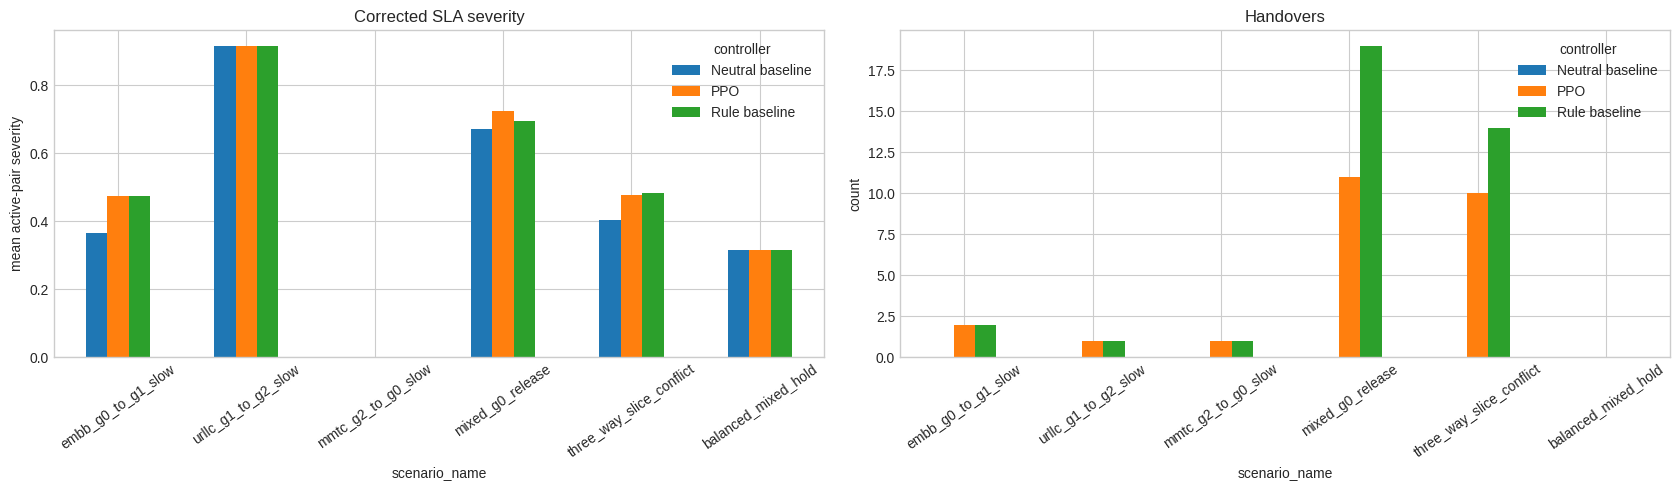

controller,Neutral baseline,PPO,Rule baseline
scenario_name,,,
embb_g0_to_g1_slow,0,13,13
urllc_g1_to_g2_slow,0,2,23
mmtc_g2_to_g0_slow,0,26,26
mixed_g0_release,0,0,4
three_way_slice_conflict,0,32,46
balanced_mixed_hold,0,0,0


In [8]:
sla_pivot = summary.pivot(index='scenario_name',columns='controller',values='mean_sla_severity').loc[SCENARIO_NAMES]
handover_pivot = summary.pivot(index='scenario_name',columns='controller',values='total_handovers').loc[SCENARIO_NAMES]
fig,axes=plt.subplots(1,2,figsize=(17,5))
sla_pivot.plot(kind='bar',ax=axes[0]); axes[0].set_title('Corrected SLA severity'); axes[0].set_ylabel('mean active-pair severity')
handover_pivot.plot(kind='bar',ax=axes[1]); axes[1].set_title('Handovers'); axes[1].set_ylabel('count')
for ax in axes: ax.tick_params(axis='x',rotation=35)
plt.tight_layout(); plt.show()

display(summary.pivot(index='scenario_name',columns='controller',values='target_safety_rejections').loc[SCENARIO_NAMES])


## Paired conclusion

The final table reports PPO improvement relative to each baseline. Positive variance delta means PPO balanced more; negative SLA delta means PPO produced lower SLA severity.

In [9]:
paired = summary.pivot(index='scenario_name',columns='controller')
conclusion = pd.DataFrame(index=SCENARIO_NAMES)
conclusion['PPO variance advantage vs rule'] = paired['variance_improvement']['PPO'] - paired['variance_improvement']['Rule baseline']
conclusion['PPO variance advantage vs neutral'] = paired['variance_improvement']['PPO'] - paired['variance_improvement']['Neutral baseline']
conclusion['PPO SLA advantage vs rule'] = paired['mean_sla_severity']['Rule baseline'] - paired['mean_sla_severity']['PPO']
conclusion['PPO handover difference vs rule'] = paired['total_handovers']['PPO'] - paired['total_handovers']['Rule baseline']
display(conclusion.round(4))

assert len(summary)==len(SCENARIO_NAMES)*3
assert np.isfinite(summary.select_dtypes(include=[np.number])).all().all()
assert traces.groupby(['scenario_name','controller']).time_s.max().nunique() >= 3
print('PASS: all controllers completed every matched scenario with finite metrics.')


,PPO variance advantage vs rule,PPO variance advantage vs neutral,PPO SLA advantage vs rule,PPO handover difference vs rule
embb_g0_to_g1_slow,0.0000,0.2222,0.0000,0
urllc_g1_to_g2_slow,0.0000,0.0000,0.0000,0
mmtc_g2_to_g0_slow,0.0000,0.0000,0.0000,0
mixed_g0_release,-0.0597,-0.1435,-0.0275,-8
three_way_slice_conflict,-0.1166,0.4989,0.0069,-4
balanced_mixed_hold,0.0000,0.0000,0.0000,0


PASS: all controllers completed every matched scenario with finite metrics.
